In [1]:
from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

The following examples introduce file operations and signal generators commonly used in DSP with Python.
Import these modules before running any of the code snippets below: 


In [2]:
import numpy as np
import scipy
import matplotlib.pyplot as plt


-----

# Loading a Wavfile with SciPy

We are using `scipy.io.wavfile.read`, you will find the documentation here:
https://docs.scipy.org/doc/scipy-1.15.0/reference/generated/scipy.io.wavfile.read.html

The file in the example below needs to be placed in the same directory, Python is currently running in. This should be the same directory the script is located in: 
https://ringbuffer.org/download/audio/210321_011_Raven.wav

Feel free to download other audio files from freesound: https://freesound.org or use any wav files on your computer.


/tmp/ipykernel_11283/157922970.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  samplerate, data = wavfile.read(wavPath);


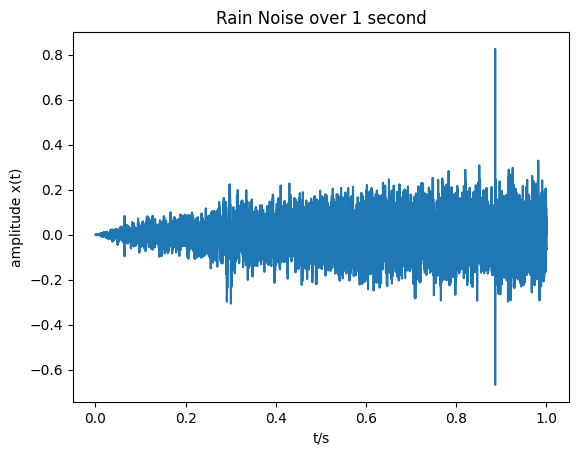

In [4]:
#Loading a signal with scipy

from scipy.io import wavfile

wavPath = "418101__buzei__vroxi.wav"
samplerate, data = wavfile.read(wavPath);

# Ensure we only take one channel, if signal is stereo
if data.ndim == 1:
    data = data
else:
    data = data[:, 0]
    
#A time axis
timeAxis = np.linspace(0,1,samplerate)

#Normalize to the peak amplitude of the signal
peakAmplitude = np.max(np.abs(data))
data = data/peakAmplitude

#plotting the loaded waveform

plt.plot(timeAxis, data[0:len(timeAxis)])
plt.xlabel("t/s")
plt.ylabel("amplitude x(t)")
plt.title("Rain Noise over 1 second")
plt.show()


-----

# Writing a Wavfile


We are using `scipy.io.wavfile.write` , you will find the documentation here: https://docs.scipy.org/doc/scipy-1.15.0/reference/generated/scipy.io.wavfile.write.html

In [6]:
from scipy.io.wavfile import write

samplerate = 48000  #48000 points every second

# 3 second of audio
timeInSeconds = 4
timeAxis  = np.linspace(0, timeInSeconds, timeInSeconds*samplerate)
freq = 200
sineWave = 0.5*np.sin(2*np.pi*freq*timeAxis)


fileName = "frstSine.wav"
write(fileName, samplerate, sineWave)

<!-- -----

# Activity - Load and Observe some Quasi-Periodic Waveforms

Explore sounds from freesound:https://freesound.org
, load the waveform and visualize it. Use the Probability Mass Function to analyze it.

Plot some:
  1. Transients (Snare drum, hand clap)
  2. Textures (Rain, Fire Crackling)
  3. Speech Signals
  4. Music Signals -->